In [28]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

In [29]:
#load the data 
df = pd.read_csv("loan_approval_dataset.csv")

In [30]:
df.head()
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


# Handle Missing Values 

In [31]:
categorial_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["int64"]).columns


In [32]:
categorial_cols

Index([' education', ' self_employed', ' loan_status'], dtype='object')

In [33]:
numerical_cols

Index(['loan_id', ' no_of_dependents', ' income_annum', ' loan_amount',
       ' loan_term', ' cibil_score', ' residential_assets_value',
       ' commercial_assets_value', ' luxury_assets_value',
       ' bank_asset_value'],
      dtype='object')

In [34]:
from sklearn.impute import SimpleImputer

num_imp =  SimpleImputer(strategy = "mean")
num_imp.fit_transform(df[numerical_cols])

array([[1.000e+00, 2.000e+00, 9.600e+06, ..., 1.760e+07, 2.270e+07,
        8.000e+06],
       [2.000e+00, 0.000e+00, 4.100e+06, ..., 2.200e+06, 8.800e+06,
        3.300e+06],
       [3.000e+00, 3.000e+00, 9.100e+06, ..., 4.500e+06, 3.330e+07,
        1.280e+07],
       ...,
       [4.267e+03, 2.000e+00, 6.500e+06, ..., 1.240e+07, 1.810e+07,
        7.300e+06],
       [4.268e+03, 1.000e+00, 4.100e+06, ..., 7.000e+05, 1.410e+07,
        5.800e+06],
       [4.269e+03, 1.000e+00, 9.200e+06, ..., 1.180e+07, 3.570e+07,
        1.200e+07]])

In [35]:
cat_imp =  SimpleImputer(strategy = "most_frequent")
df[categorial_cols] = cat_imp.fit_transform(df[categorial_cols])

In [36]:
df.head()
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

# EDA - exploratory data analysis


In [37]:
# 1. Strip leading and trailing spaces from column names
df.columns = df.columns.str.strip()

# 2. Strip leading/trailing spaces from text values (e.g., ' Approved' -> 'Approved')
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

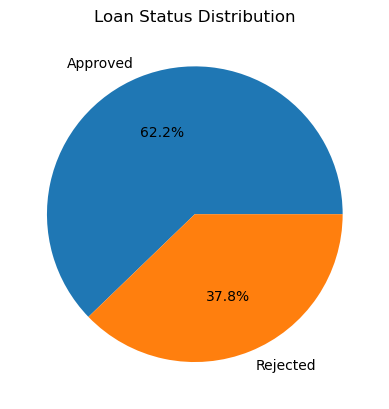

In [38]:
#how banlanced our categorial feature??
classes_count = df["loan_status"].value_counts()

plt.pie(classes_count,
        labels=classes_count.index,
        autopct="%1.1f%%")

plt.title("Loan Status Distribution")
plt.show()

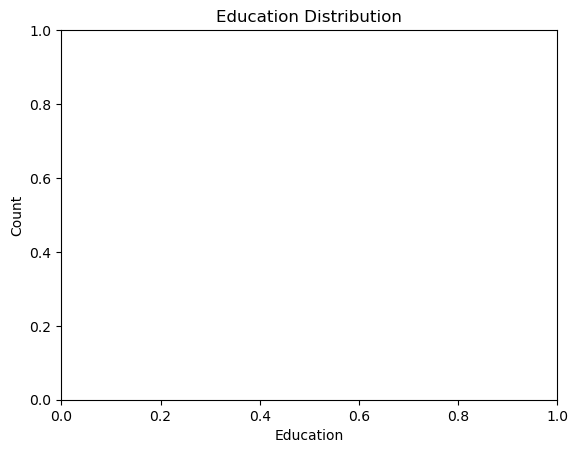

In [39]:
#analyzee categorial
education_cnt = df["education"].value_counts()

sns.barplot(X=education_cnt.index, Y=education_cnt.values)

plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

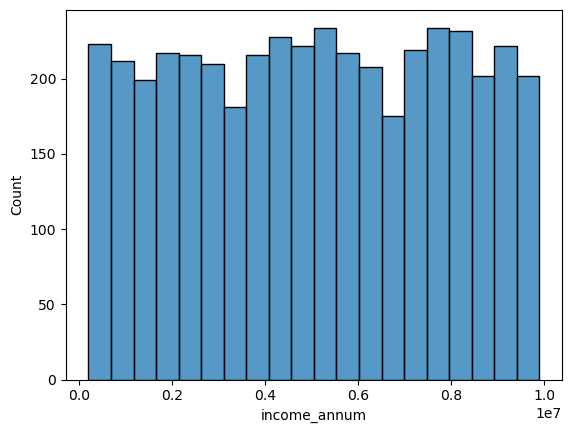

In [40]:
#analize income 
sns.histplot(
    data=df,
    x="income_annum",
    bins=20
)

plt.show()

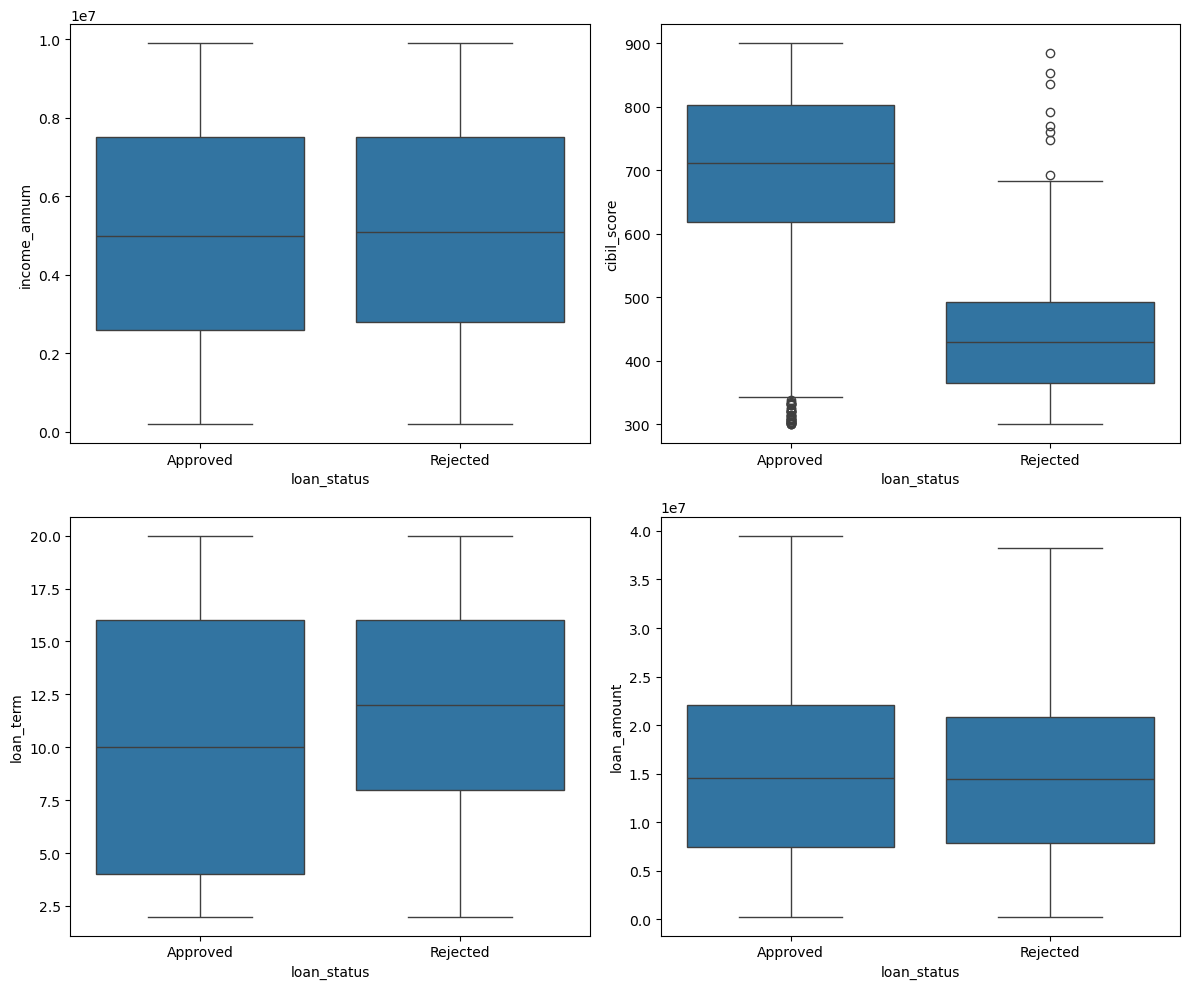

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(ax=axes[0, 0], data=df, x='loan_status', y='income_annum')
sns.boxplot(ax=axes[0, 1], data=df, x='loan_status', y='cibil_score')
sns.boxplot(ax=axes[1, 0], data=df, x='loan_status', y='loan_term')
sns.boxplot(ax=axes[1, 1], data=df, x='loan_status', y='loan_amount')

plt.tight_layout()
plt.show()

<Axes: xlabel='cibil_score', ylabel='Count'>

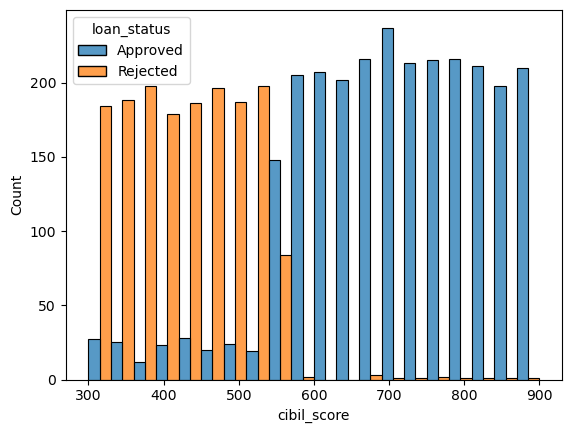

In [42]:
sns.histplot(
    data = df,
    x = "cibil_score",
    hue = "loan_status",
    bins=20,
    multiple="dodge"
)

# Encoding

In [43]:
df.head()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [91]:
from sklearn.preprocessing import OneHotEncoder

# Initialize encoder
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit and transform categorical columns
encoded_array = ohe.fit_transform(df[['education', 'self_employed']])

# Convert back to DataFrame with proper feature names
encoded_df = pd.DataFrame(
    encoded_array, 
    columns=ohe.get_feature_names_out(['education', 'self_employed'])
)

# Correlation Heatmap 

loan_id                    NaN
no_of_dependents           NaN
income_annum               NaN
loan_amount                NaN
loan_term                  NaN
cibil_score                NaN
residential_assets_value   NaN
commercial_assets_value    NaN
luxury_assets_value        NaN
bank_asset_value           NaN
loan_status_numeric        NaN
Name: loan_status_numeric, dtype: float64

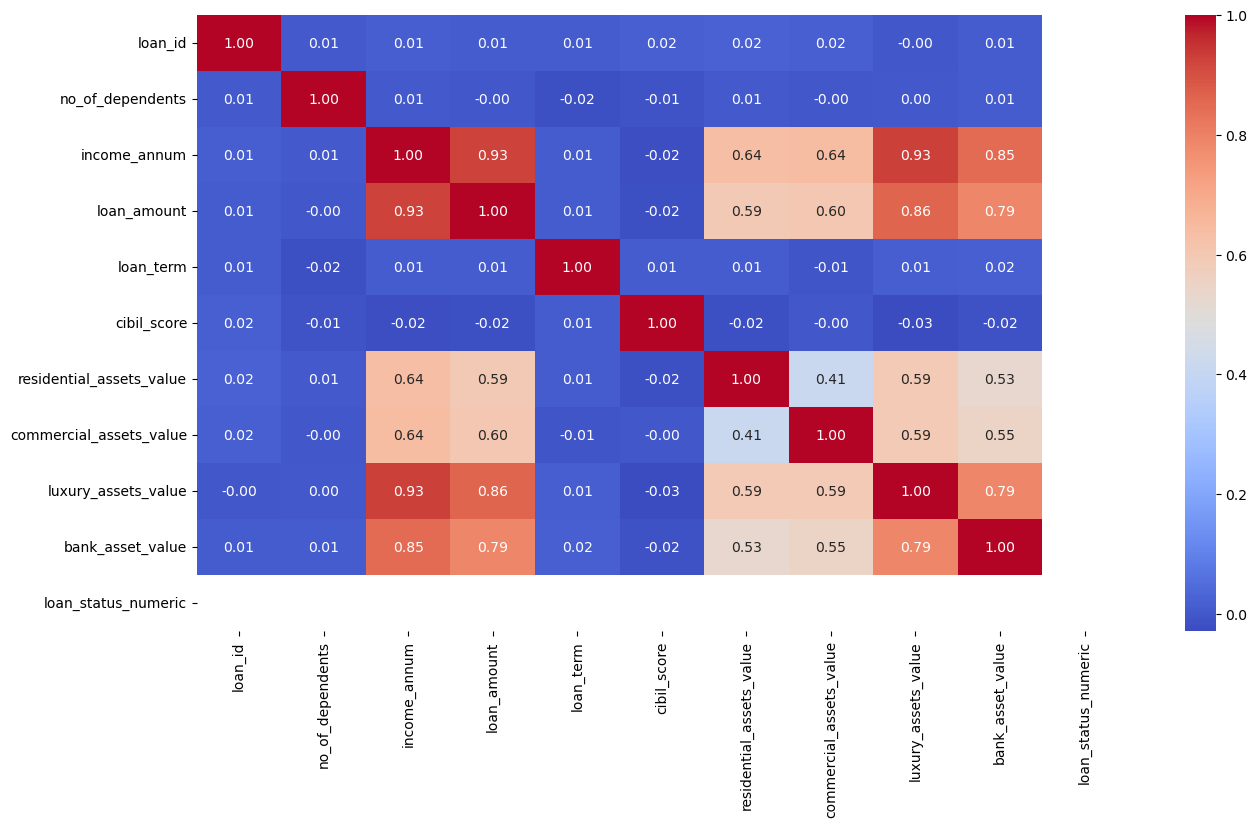

In [60]:
# 1. Map text categories to binary numbers
df['loan_status_numeric'] = df['loan_status'].map({'Paid': 0, 'Default': 1})  # Adjust values to match your dataset

# 2. Select numeric columns and calculate correlation
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# 3. Sort correlations against loan status
corr_matrix["loan_status_numeric"].sort_values(ascending=False)

# Train-Test-Split + Feature Scaling

In [61]:
X = df.drop("loan_status",axis=1)
Y = df["loan_status"]

In [62]:
X.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status_numeric
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,NaN
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,NaN
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,NaN
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,NaN
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,NaN


In [66]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [67]:
X_test.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status_numeric
1703,1704,5,Graduate,No,5400000,19700000,20,423,6500000,10000000,15700000,7300000,NaN
1173,1174,2,Graduate,No,5900000,14000000,8,599,4700000,9500000,17800000,6700000,NaN
308,309,3,Graduate,No,9600000,19900000,14,452,4200000,16200000,28500000,6600000,NaN
1322,1323,2,Graduate,No,6200000,23400000,8,605,10000000,10800000,21800000,9200000,NaN
3271,3272,3,Not Graduate,Yes,5800000,14100000,12,738,11700000,4400000,15400000,8400000,NaN


In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 1. Clean strings & map target column accurately
# (Adjust keys below to match what you saw in value_counts)
df['loan_status_cleaned'] = df['loan_status'].astype(str).str.strip()
y = df['loan_status_cleaned'].map({'Paid': 0, 'Default': 1})

# 2. Separate features X and drop ALL target variations
X = df.drop(columns=['loan_status', 'loan_status_cleaned'], errors='ignore')

# Drop 'loan_status_numeric' if it exists in df from previous runs
if 'loan_status_numeric' in X.columns:
    X = X.drop(columns=['loan_status_numeric'])

# 3. One-hot encode remaining text categories in X
X = pd.get_dummies(X, drop_first=True)

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Impute Missing Values
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 6. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Pipeline executed successfully! Scaled shape:", X_train_scaled.shape)

Pipeline executed successfully! Scaled shape: (3415, 12)


In [75]:
X_train_scaled

array([[-0.38682838,  1.51250774,  1.00950021, ...,  1.16041374,
         1.00263891, -1.01504731],
       [-0.80430304, -1.43500078,  1.61417128, ...,  0.88201987,
         1.00263891,  0.98517575],
       [-1.59840356, -0.84549907, -1.51589075, ..., -1.31419838,
        -0.99736803, -1.01504731],
       ...,
       [ 0.7708264 ,  0.92300603,  1.25848241, ...,  0.13963624,
         1.00263891,  0.98517575],
       [ 1.32636998, -0.25599737,  0.68938023, ...,  1.4388076 ,
         1.00263891,  0.98517575],
       [-1.0526637 ,  0.92300603,  0.40482913, ..., -0.10782497,
        -0.99736803, -1.01504731]])

# train & Evaluate Models

In [83]:
#Logistic regression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
# 1. Map target labels to 1 and 0 before splitting
Y = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

# 2. Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. Fit model and predict
log_model = LogisticRegression()
log_model.fit(X_train_scaled, Y_train)
Y_pred = log_model.predict(X_test_scaled)

# 4. Standard metrics will now work automatically
print("precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1 score:", f1_score(Y_test, Y_pred))
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("CM:\n", confusion_matrix(Y_test, Y_pred))  

precision: 0.9208103130755064
Recall: 0.9328358208955224
F1 score: 0.9267840593141798
Accuracy: 0.9074941451990632
CM:
 [[275  43]
 [ 36 500]]


In [85]:
#knn
from sklearn.neighbors import KNeighborsClassifier

# 3. Fit model and predict
log_model = KNeighborsClassifier(n_neighbors=7)
log_model.fit(X_train_scaled, Y_train)
Y_pred = log_model.predict(X_test_scaled)


# 4. Standard metrics will now work automatically
print("precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1 score:", f1_score(Y_test, Y_pred))
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("CM:\n", confusion_matrix(Y_test, Y_pred))  


precision: 0.9108159392789373
Recall: 0.8955223880597015
F1 score: 0.90310442144873
Accuracy: 0.8793911007025761
CM:
 [[271  47]
 [ 56 480]]


In [88]:
#naive bayes
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, Y_train)
Y_pred = nb_model.predict(X_test_scaled)
# 4. Standard metrics will now work automatically
print("precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1 score:", f1_score(Y_test, Y_pred))
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("CM:\n", confusion_matrix(Y_test, Y_pred))  


precision: 0.9580152671755725
Recall: 0.9365671641791045
F1 score: 0.9471698113207547
Accuracy: 0.9344262295081968
CM:
 [[296  22]
 [ 34 502]]


## Best Model On the basic of Precision=>Naive Bayes

# Feature Enginering

In [3]:
import pandas as pd
import numpy as np

# 1. Load your dataset (replace with your actual file name)
df = pd.read_csv("loan_approval_dataset.csv")

# 2. Now run your feature engineering code safely
if "cibil_score" in df.columns:
    df["cibil_score_sq"] = df["cibil_score"] ** 2

if "loan_term" in df.columns:
    df["loan_term_sq"] = df["loan_term"] ** 2

if "income" in df.columns:
    df["income_log"] = np.log1p(df["income"])